# Homework 01: Moneyball Analysis

This notebook contains the complete analysis for the assignment. It begins by understanding the training and evaluation data, then continues through data preparation, multiple linear regression, model evaluation, and predictions.

The data represents professional baseball teams from 1871 through 2006. The assignment asks us to predict `TARGET_WINS` using the variables provided in the training data.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

training_path = Path("../data/moneyball-training-data.csv")
evaluation_path = Path("../data/moneyball-evaluation-data.csv")

## 1. Exploratory Data Analysis

The goal is to understand the variables, check the quality of the data, and identify possible relationships with wins before fitting a model. The dependent variable is `TARGET_WINS`. The evaluation data does not contain that variable and will be used later for predictions. `INDEX` is an identification variable and should not be used as a predictor.

### Load the datasets

The notebook is stored in `homeworks/hw01/notebooks/`, so the data files are one folder above in `../data/`.

In [59]:
training = pd.read_csv(training_path)
evaluation = pd.read_csv(evaluation_path)

print(f"Training file loaded from: {training_path}")
print(f"Evaluation file loaded from: {evaluation_path}")

Training file loaded from: ..\data\moneyball-training-data.csv
Evaluation file loaded from: ..\data\moneyball-evaluation-data.csv


### Dataset dimensions

The training and evaluation files should have the same predictor columns. The training file also includes `TARGET_WINS`.

In [60]:
dataset_dimensions = pd.DataFrame({
    "dataset": ["Training", "Evaluation"],
    "rows": [len(training), len(evaluation)],
    "columns": [training.shape[1], evaluation.shape[1]],
})
display(dataset_dimensions)

print("Training columns:")
print(training.columns.tolist())
print("Evaluation columns:")
print(evaluation.columns.tolist())

,dataset,rows,columns
0,Training,2276,17
1,Evaluation,259,16


Training columns:
['INDEX', 'TARGET_WINS', 'TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']
Evaluation columns:
['INDEX', 'TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']


### Identify the dependent and independent variables

The dependent variable, also called the response variable, is `TARGET_WINS`. It is the number of wins we want to predict.

The independent variables are the baseball performance statistics used to explain or predict `TARGET_WINS`. `INDEX` is not an independent variable because it only identifies a row and should not be used in the model.

In [61]:
dependent_variable = "TARGET_WINS"
independent_variables = [
    column for column in training.columns
    if column not in {dependent_variable, "INDEX"}
]

print("Dependent variable:")
print(dependent_variable)
print("Independent variables:")
print(independent_variables)

Dependent variable:
TARGET_WINS
Independent variables:
['TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']


### Compare the column names

This check confirms which columns are shared and which columns occur in only one file. The target should be present only in the training data.

In [62]:
all_columns = list(dict.fromkeys([*training.columns, *evaluation.columns]))
column_comparison = pd.DataFrame({
    "in_training": [column in training.columns for column in all_columns],
    "in_evaluation": [column in evaluation.columns for column in all_columns],
}, index=all_columns)
column_comparison.index.name = "column"
display(column_comparison)

,in_training,in_evaluation
column,,
INDEX,True,True
TARGET_WINS,True,False
TEAM_BATTING_H,True,True
TEAM_BATTING_2B,True,True
TEAM_BATTING_3B,True,True
TEAM_BATTING_HR,True,True
TEAM_BATTING_BB,True,True
TEAM_BATTING_SO,True,True
TEAM_BASERUN_SB,True,True


### Inspect the structure and data types

The variables are expected to be numeric because they represent counts of baseball events or wins.

In [63]:
training.info()
type_summary = pd.DataFrame({
    "class": training.dtypes.astype(str),
    "distinct_values": training.nunique(dropna=True),
})
type_summary.index.name = "column"
display(type_summary)

<class 'pandas.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   INDEX             2276 non-null   int64  
 1   TARGET_WINS       2276 non-null   int64  
 2   TEAM_BATTING_H    2276 non-null   int64  
 3   TEAM_BATTING_2B   2276 non-null   int64  
 4   TEAM_BATTING_3B   2276 non-null   int64  
 5   TEAM_BATTING_HR   2276 non-null   int64  
 6   TEAM_BATTING_BB   2276 non-null   int64  
 7   TEAM_BATTING_SO   2174 non-null   float64
 8   TEAM_BASERUN_SB   2145 non-null   float64
 9   TEAM_BASERUN_CS   1504 non-null   float64
 10  TEAM_BATTING_HBP  191 non-null    float64
 11  TEAM_PITCHING_H   2276 non-null   int64  
 12  TEAM_PITCHING_HR  2276 non-null   int64  
 13  TEAM_PITCHING_BB  2276 non-null   int64  
 14  TEAM_PITCHING_SO  2174 non-null   float64
 15  TEAM_FIELDING_E   2276 non-null   int64  
 16  TEAM_FIELDING_DP  1990 non-null   float64
dtypes: flo

,class,distinct_values
column,,
INDEX,int64,2276
TARGET_WINS,int64,108
TEAM_BATTING_H,int64,569
TEAM_BATTING_2B,int64,240
TEAM_BATTING_3B,int64,144
TEAM_BATTING_HR,int64,243
TEAM_BATTING_BB,int64,533
TEAM_BATTING_SO,float64,822
TEAM_BASERUN_SB,float64,348


### Check missing values

Missing values need to be understood before modeling. This table shows the count and percentage of missing values in each column.

In [64]:
missing_summary = pd.DataFrame({
    "missing_count": training.isna().sum(),
    "missing_percent": (100 * training.isna().mean()).round(2),
}).sort_values("missing_count", ascending=False)
missing_summary.index.name = "column"
display(missing_summary)

,missing_count,missing_percent
column,,
TEAM_BATTING_HBP,2085,91.61
TEAM_BASERUN_CS,772,33.92
TEAM_FIELDING_DP,286,12.57
TEAM_BASERUN_SB,131,5.76
TEAM_PITCHING_SO,102,4.48
TEAM_BATTING_SO,102,4.48
INDEX,0,0.00
TARGET_WINS,0,0.00
TEAM_BATTING_H,0,0.00


### Review summary statistics

The minimum, median, mean, and maximum values help show the scale and spread of the variables.

In [65]:
display(training.describe().T)

,count,mean,std,min,25%,50%,75%,max
INDEX,2276.0,1268.463533,736.349040,1.0,630.75,1270.5,1915.50,2535.0
TARGET_WINS,2276.0,80.790861,15.752152,0.0,71.00,82.0,92.00,146.0
TEAM_BATTING_H,2276.0,1469.269772,144.591195,891.0,1383.00,1454.0,1537.25,2554.0
TEAM_BATTING_2B,2276.0,241.246924,46.801415,69.0,208.00,238.0,273.00,458.0
TEAM_BATTING_3B,2276.0,55.250000,27.938557,0.0,34.00,47.0,72.00,223.0
TEAM_BATTING_HR,2276.0,99.612039,60.546872,0.0,42.00,102.0,147.00,264.0
TEAM_BATTING_BB,2276.0,501.558875,122.670862,0.0,451.00,512.0,580.00,878.0
TEAM_BATTING_SO,2174.0,735.605336,248.526418,0.0,548.00,750.0,930.00,1399.0
TEAM_BASERUN_SB,2145.0,124.761772,87.791166,0.0,66.00,101.0,156.00,697.0
TEAM_BASERUN_CS,1504.0,52.803856,22.956338,0.0,38.00,49.0,62.00,201.0


In the summary table, `TARGET_WINS` has a mean of 80.8, a median of 82, and quartiles of 71 and 92. `TEAM_BATTING_HBP` has 191 non-missing values, compared with 2,276 for `TARGET_WINS`, so this predictor has substantially fewer recorded observations. The table describes the amount of missing data but does not show why those values are missing.

### Examine the target variable

`TARGET_WINS` is the response variable for the regression model. We will review its distribution and summary statistics before modeling.

In [66]:
target_summary = training["TARGET_WINS"].describe().to_frame().T
target_summary.index = ["TARGET_WINS"]
display(target_summary)

,count,mean,std,min,25%,50%,75%,max
TARGET_WINS,2276.0,80.790861,15.752152,0.0,71.0,82.0,92.0,146.0


The table summarizes `TARGET_WINS` for 2,276 teams. The mean is about 80.8 wins and the median is 82, so the center is around 81 wins. The middle half of teams recorded 71 to 92 wins, while the full range is 0 to 146 wins (standard deviation: about 15.8). The histogram below shows the shape of this distribution.

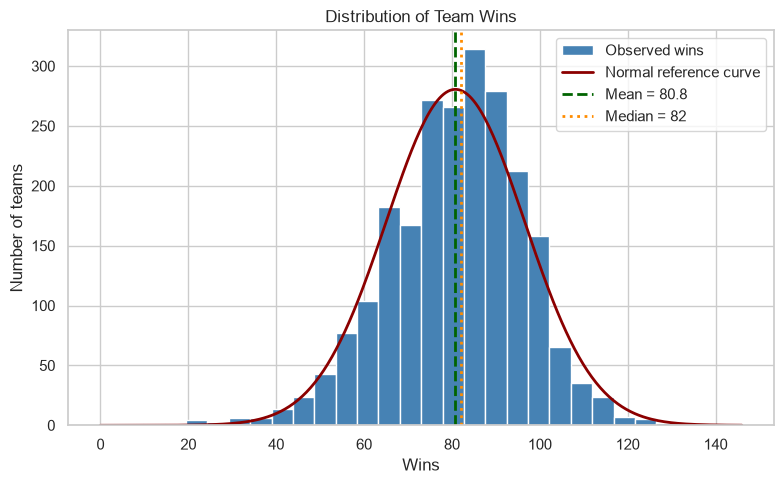

In [67]:
wins = training["TARGET_WINS"].dropna()
bin_edges = np.histogram_bin_edges(wins, bins=30)
bin_width = np.diff(bin_edges).mean()
normal_x = np.linspace(wins.min(), wins.max(), 300)
normal_mean = wins.mean()
normal_median = wins.median()
normal_std = wins.std(ddof=1)
normal_counts = (
    len(wins) * bin_width / (normal_std * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((normal_x - normal_mean) / normal_std) ** 2)
)

plt.figure(figsize=(8, 5))
plt.hist(wins, bins=bin_edges, color="steelblue", edgecolor="white", label="Observed wins")
plt.plot(normal_x, normal_counts, color="darkred", linewidth=2, label="Normal reference curve")
plt.axvline(normal_mean, color="darkgreen", linestyle="--", linewidth=2,
            label=f"Mean = {normal_mean:.1f}")
plt.axvline(normal_median, color="darkorange", linestyle=":", linewidth=2,
            label=f"Median = {normal_median:.0f}")
plt.title("Distribution of Team Wins")
plt.xlabel("Wins")
plt.ylabel("Number of teams")
plt.legend()
plt.tight_layout()
plt.show()

Most teams are concentrated around 70–100 wins, with the highest bars near 80–85 wins. The red curve shows the counts expected from a normal distribution with the same mean and standard deviation as `TARGET_WINS`; the bars broadly follow its central shape but differ in places, especially toward the tails. This is a visual reference only. The regression normality assumption should be assessed using model residuals, not the response histogram alone.

### Explore relationships between selected predictors and wins

The following plots compare team batting home runs and walks with `TARGET_WINS`. The fitted lines summarize the direction of each pairwise linear association.

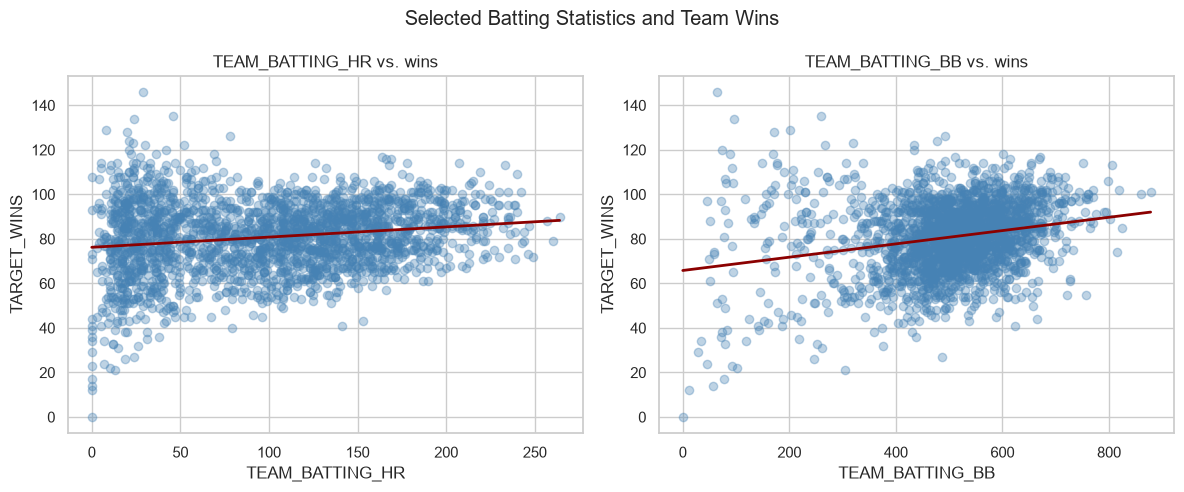

In [68]:
predictor_columns = ["TEAM_BATTING_HR", "TEAM_BATTING_BB"]
fig, axes = plt.subplots(1, len(predictor_columns), figsize=(12, 5))

for ax, predictor in zip(axes, predictor_columns):
    plot_data = training[[predictor, "TARGET_WINS"]].dropna()
    ax.scatter(plot_data[predictor], plot_data["TARGET_WINS"], alpha=0.35, color="steelblue")
    slope, intercept = np.polyfit(plot_data[predictor], plot_data["TARGET_WINS"], 1)
    trend_x = np.linspace(plot_data[predictor].min(), plot_data[predictor].max(), 100)
    ax.plot(trend_x, slope * trend_x + intercept, color="darkred", linewidth=2)
    ax.set_title(f"{predictor} vs. wins")
    ax.set_xlabel(predictor)
    ax.set_ylabel("TARGET_WINS")

fig.suptitle("Selected Batting Statistics and Team Wins")
fig.tight_layout()
plt.show()

Both plots show a positive pairwise association: teams with more batting home runs or walks tend to have more wins on average. The wide vertical spread at many predictor values shows that neither statistic alone explains wins; other batting, pitching, and fielding factors also matter. These trend lines describe association, not causation, and do not control for the other predictors that will be considered in the regression models.

### Correlations among wins and numeric statistics

The heatmap summarizes pairwise Pearson correlations for `TARGET_WINS` and the numeric baseball statistics. `INDEX` is excluded because it is only an identifier.

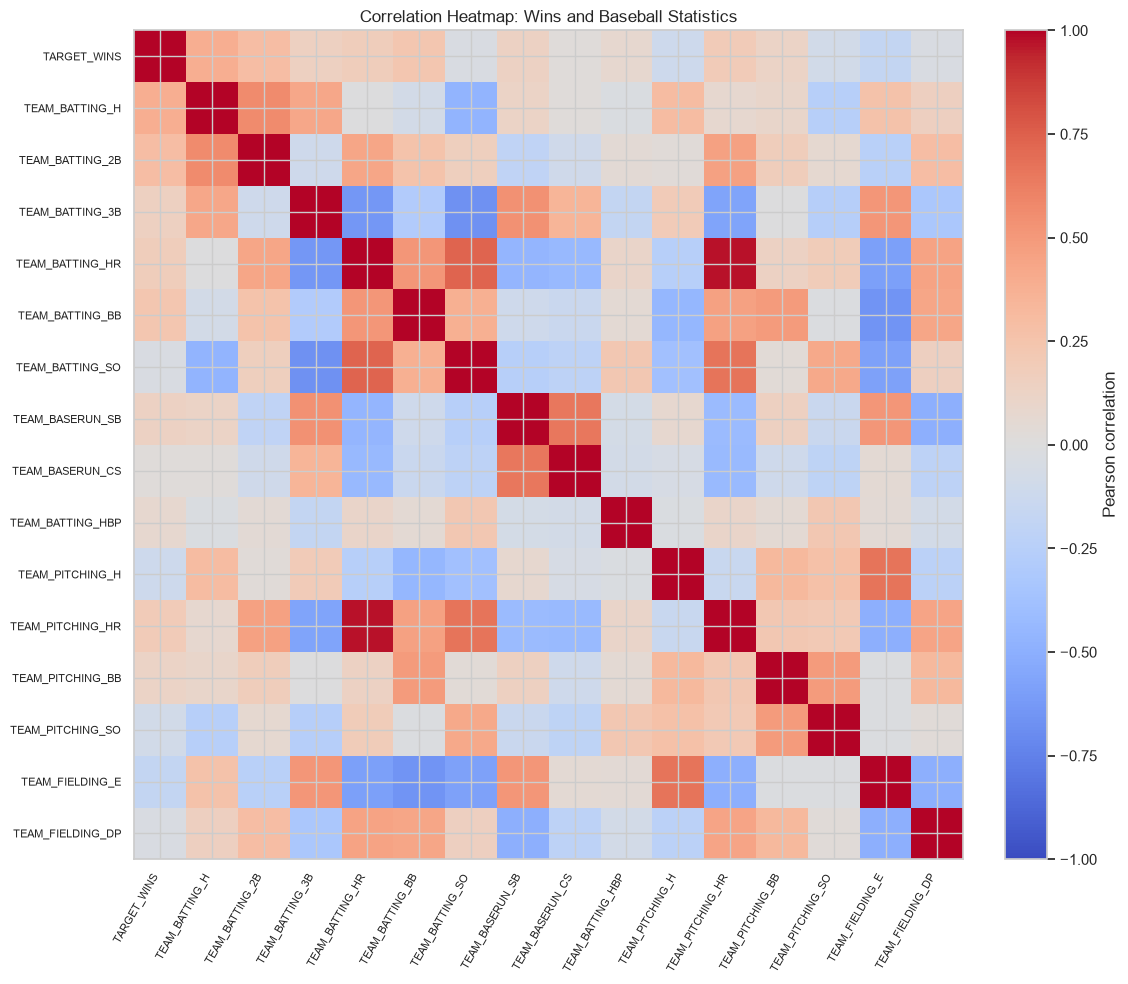

In [69]:
correlation_data = training.select_dtypes(include="number").drop(columns="INDEX", errors="ignore")
correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticklabels(correlation_matrix.columns, fontsize=8)
ax.set_title("Correlation Heatmap: Wins and Baseball Statistics")
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Pearson correlation")
fig.tight_layout()
plt.show()

Red cells indicate positive correlations and blue cells indicate negative correlations; stronger colors represent stronger linear associations. The `TARGET_WINS` row/column shows mostly modest correlations with individual statistics, while some predictors are strongly correlated with one another. Those predictor to predictor relationships are worth considering when interpreting a multiple regression because they can indicate multicollinearity. Correlations use available pairs of values, so the number of observations can differ across cells when data are missing. Correlation does not establish causation.

### Section 1 conclusion

**EDA findings:** `TARGET_WINS` is centered near 81 wins (mean 80.8; median 82). The scatter plots show positive unadjusted relationships between wins and both batting home runs and walks. The heatmap shows some predictors are correlated with each other. `TEAM_BATTING_HBP` has only 191 observed values, and `TEAM_PITCHING_H` has a maximum of 30,132 compared with a median of 1,518.

**Datasets**

- Training: `../data/moneyball-training-data.csv` (2,276 rows, 17 columns), loaded in Python as `training`; includes the response variable `TARGET_WINS`.
- Evaluation: `../data/moneyball-evaluation-data.csv` (259 rows, 16 columns), loaded in Python as `evaluation`; has the same predictor columns as training but no `TARGET_WINS` values.

Both files contain team level batting, baserunning, pitching, and fielding statistics. `INDEX` is a row identifier and should not be used as a predictor.

## 2. Data Preparation


## 3. Build Models

## 4. Select Models


## 5. Predictions for the evaluation data



## 6. Prepare the Final Report

